# PS 26054 — XGBoost Engine Degradation Estimation

**Goal:** estimate continuous engine degradation (0–1) from raw engine/environment sensor behaviour.

Pipeline: **raw sensors → physics residuals → operating-condition features → causal temporal features → XGBoost regressor → degradation estimate**

Modelling policy:
- Mission-level split: 58 train / 21 validation / 21 test.
- No row-wise random split.
- Do not use fault labels, RUL, health index, failure flag, IDs, mission type, timestamp, or degradation as features.
- No StandardScaler: XGBoost does not require feature scaling.
- Temporal features use only current/past samples within the same mission.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 01 - Imports + configuration

import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET = "degradation"
USE_GPU = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.5f}")

In [3]:
# 02 - Load CSV

candidate_paths = [
    "/content/MALE_UAV_aero_piston_engine_final_100k.csv",
    "/mnt/data/MALE_UAV_aero_piston_engine_final_100k.csv",
]
DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)

if DATA_PATH is None:
    matches = glob.glob("/kaggle/input/**/MALE_UAV_aero_piston_engine_final_100k.csv", recursive=True)
    if matches:
        DATA_PATH = matches[0]

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = next(iter(uploaded))
    except Exception:
        raise FileNotFoundError("Upload MALE_UAV_aero_piston_engine_final_100k.csv and rerun.")

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Loaded: /content/MALE_UAV_aero_piston_engine_final_100k.csv
Shape: (100000, 34)


,timestamp_s,engine_id,mission_id,mission_type,altitude_m,ambient_temp_C,pressure_kPa,air_density_kg_m3,throttle_pct,load_pct,rpm,air_mass_flow_kg_s,fuel_flow_kg_s,torque_Nm,power_W,cht_C,egt_C,oil_temperature_C,oil_pressure_bar,vibration_rms,battery_voltage_V,alternator_current_A,alternator_health,injection_timing_deg,expected_rpm,expected_cht_C,expected_egt_C,physics_residual_C,health_index,fault_type,fault_severity,degradation,failure_flag,rul_hours
0,0,ENGINE_001,1,normal_isr,15.24000,25.00000,100.72600,1.17692,70.00000,70.75000,2317.25000,0.06444,0.00501,251.53000,61036.10000,132.89000,665.45000,74.30000,3.76600,0.75290,28.07700,40.55000,1.00000,24.59000,2307.45000,134.10000,673.08000,-1.21000,97.31000,normal,0.00000,0.00000,0,NaN
1,1,ENGINE_001,1,normal_isr,30.48000,25.01000,100.12900,1.16992,70.00000,69.79000,2304.40000,0.06346,0.00493,240.38000,58006.50000,132.64000,665.94000,73.54000,3.76600,0.71480,28.10700,40.63000,1.00000,24.76100,2297.93000,132.69000,669.38000,-0.04000,97.31000,normal,0.00000,0.00000,0,NaN
2,2,ENGINE_001,1,normal_isr,45.72000,25.02000,99.53600,1.16296,70.00000,70.97000,2310.13000,0.06353,0.00503,251.98000,60957.20000,134.65000,672.55000,73.57000,3.76200,0.74230,28.05000,40.69000,1.00000,24.87000,2309.72000,134.62000,674.20000,0.03000,97.28000,normal,0.00000,0.00000,0,NaN
3,3,ENGINE_001,1,normal_isr,60.96000,25.02000,98.94500,1.15602,70.00000,72.28000,2318.32000,0.06370,0.00521,253.76000,61605.20000,137.43000,687.11000,75.67000,3.79200,0.80480,27.80600,41.80000,1.00000,24.85700,2322.85000,136.77000,679.56000,0.66000,97.50000,normal,0.00000,0.00000,0,NaN
4,4,ENGINE_001,1,normal_isr,76.20000,25.03000,98.35800,1.14912,70.00000,69.65000,2301.38000,0.06222,0.00483,247.29000,59597.00000,130.79000,671.35000,74.33000,3.77900,0.81970,27.98400,42.09000,1.00000,24.83600,2296.49000,132.71000,669.12000,-1.91000,97.40000,normal,0.00000,0.00000,0,NaN


In [ ]:
# 03 - Dataset sanity check

print("Missions:", df.mission_id.nunique())
print("Rows/mission:", df.groupby("mission_id").size().unique())
print("\nTarget summary:")
display(df[TARGET].describe().to_frame())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDegradation == 0:", (df[TARGET] == 0).sum())
print("Degradation > 0 :", (df[TARGET] > 0).sum())

Missions: 100
Rows/mission: [1000]

Target summary:


,degradation
count,100000.00000
mean,0.12760
std,0.26217
min,0.00000
25%,0.00000
50%,0.00000
75%,0.02110
max,0.99890



Missing values:


,0
rul_hours,70000
timestamp_s,0
engine_id,0
mission_id,0
altitude_m,0
mission_type,0
pressure_kPa,0
air_density_kg_m3,0
throttle_pct,0
ambient_temp_C,0



Degradation == 0: 74480
Degradation > 0 : 25520


## Stage A — feature distributions

This is **EDA, not feature selection**. We compare healthy (`degradation == 0`) and degraded (`degradation > 0`) samples to understand which physical signals visibly change.

For the continuous target, we also rank candidate features by Spearman correlation. The model will still use the complete allowed feature set rather than selecting only these top features.

Top continuous relationships (absolute Spearman):


,abs_spearman
vibration_rms,0.66784
physics_residual_C,0.60993
cht_C,0.39233
ambient_temp_C,0.34261
oil_temperature_C,0.33872
egt_C,0.29763
injection_timing_deg,0.26941
oil_pressure_bar,0.19743
expected_cht_C,0.17337
expected_egt_C,0.14753


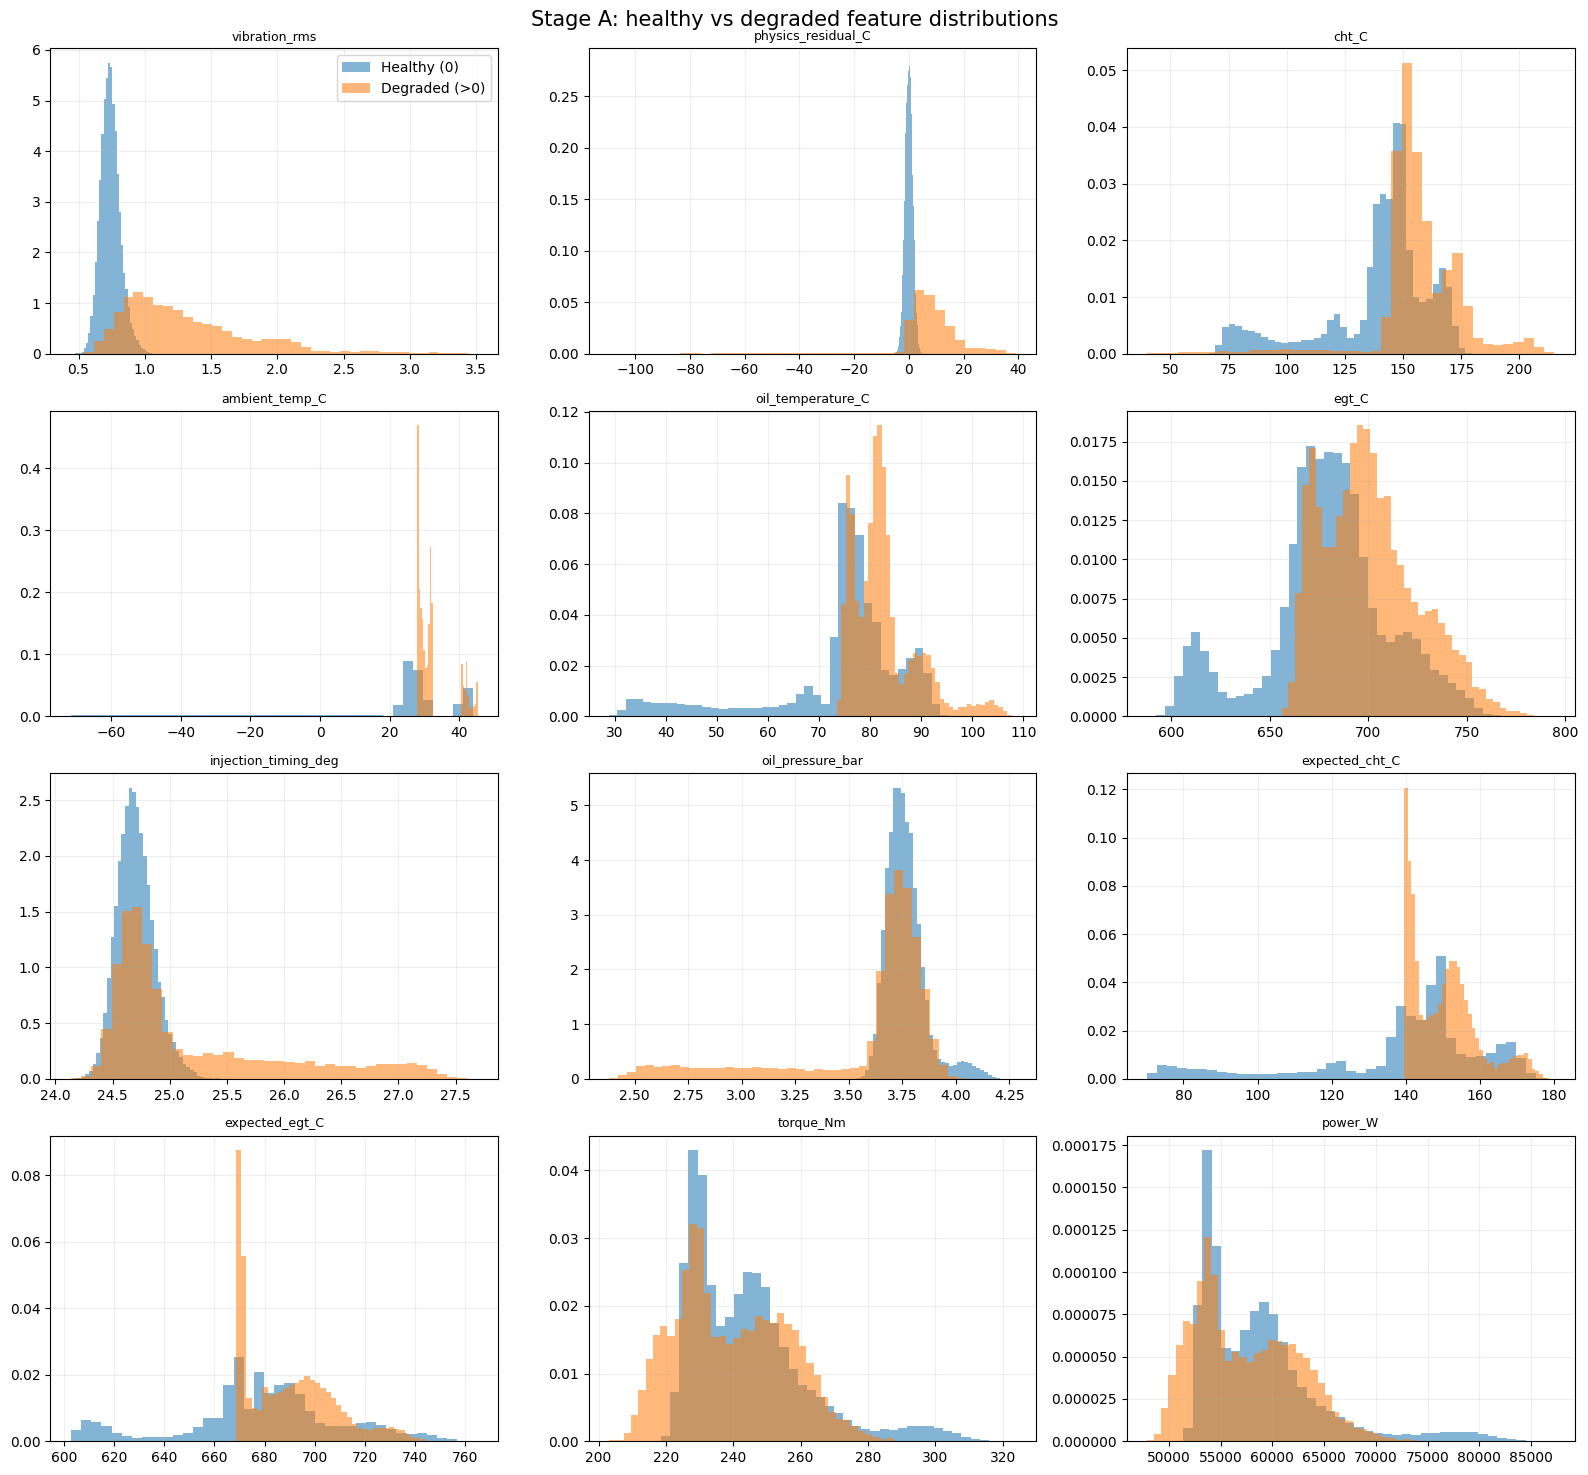

In [6]:
import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET = "degradation"
USE_GPU = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.5f}")

TRAIN_MISSIONS = [
    2,3,4,7,9,12,14,15,16,18,20,21,22,24,25,26,27,28,30,33,
    37,38,39,40,42,44,47,49,51,52,53,56,57,60,61,62,64,65,
    66,67,69,70,73,74,75,77,78,80,83,84,85,87,89,91,92,94,96,100
]
VAL_MISSIONS = [5,8,11,17,29,32,34,41,45,48,50,58,59,63,76,79,81,82,90,95,98]
TEST_MISSIONS = [1,6,10,13,19,23,31,35,36,43,46,54,55,68,71,72,86,88,93,97,99]

assert len(TRAIN_MISSIONS) == 58 and len(VAL_MISSIONS) == 21 and len(TEST_MISSIONS) == 21
assert not (set(TRAIN_MISSIONS) & set(VAL_MISSIONS) | set(TRAIN_MISSIONS) & set(TEST_MISSIONS) | set(VAL_MISSIONS) & set(TEST_MISSIONS))

eda = df[df.mission_id.isin(TRAIN_MISSIONS)].copy()
candidate_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c])
    and c not in ["timestamp_s","mission_id","fault_severity","degradation",
                  "failure_flag","rul_hours","health_index","alternator_health"]
]

rank = eda[candidate_cols + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top12 = rank.head(12).index.tolist()

print("Top continuous relationships (absolute Spearman):")
display(rank.head(15).to_frame("abs_spearman"))

fig, axes = plt.subplots(4, 3, figsize=(16, 15))
for ax, feature in zip(axes.ravel(), top12):
    ax.hist(eda.loc[eda[TARGET] == 0, feature].dropna(), bins=40, alpha=.55, density=True, label="Healthy (0)")
    ax.hist(eda.loc[eda[TARGET] > 0, feature].dropna(), bins=40, alpha=.55, density=True, label="Degraded (>0)")
    ax.set_title(feature, fontsize=9)
    ax.grid(alpha=.2)
axes[0, 0].legend()
plt.suptitle("Stage A: healthy vs degraded feature distributions", fontsize=15)
plt.tight_layout()
plt.show()

In [7]:
# 05 - Stage A: numerical distribution summary

rows = []
for feature in top12:
    h = eda.loc[eda[TARGET] == 0, feature].dropna()
    d = eda.loc[eda[TARGET] > 0, feature].dropna()
    rows.append({
        "feature": feature,
        "healthy_median": h.median(),
        "degraded_median": d.median(),
        "median_shift": d.median() - h.median(),
        "abs_spearman": rank[feature],
    })
display(pd.DataFrame(rows).sort_values("abs_spearman", ascending=False))

,feature,healthy_median,degraded_median,median_shift,abs_spearman
0,vibration_rms,0.73620,1.19110,0.45490,0.66784
1,physics_residual_C,-0.01000,7.24000,7.25000,0.60993
2,cht_C,145.43000,155.02000,9.59000,0.39233
3,ambient_temp_C,26.52000,30.39000,3.87000,0.34261
4,oil_temperature_C,76.63000,81.49000,4.86000,0.33872
5,egt_C,680.10000,698.22000,18.12000,0.29763
6,injection_timing_deg,24.69000,24.82600,0.13600,0.26941
7,oil_pressure_bar,3.75200,3.71900,-0.03300,0.19743
8,expected_cht_C,145.62000,149.55000,3.93000,0.17337
9,expected_egt_C,679.70000,687.86500,8.16500,0.14753


## Feature policy

Excluded from model inputs:

`engine_id, mission_id, mission_type, fault_type, fault_severity, failure_flag, degradation, rul_hours, health_index, alternator_health, timestamp_s`

We intentionally infer degradation from **raw sensor behaviour + physics residuals + operating-condition relationships + temporal behaviour**.

In [8]:
# 06 - Sort chronologically within each mission

EXCLUDE = [
    "timestamp_s","engine_id","mission_id","mission_type",
    "fault_type","fault_severity","degradation","failure_flag",
    "rul_hours","health_index","alternator_health"
]

data = df.sort_values(["mission_id","timestamp_s"]).reset_index(drop=True).copy()
assert data.groupby("mission_id")["timestamp_s"].apply(lambda s: s.is_monotonic_increasing).all()
print("Mission chronology verified.")

Mission chronology verified.


In [9]:
# 07 - Physics-informed features

# Existing physics_residual_C is retained; we do NOT recreate a duplicate CHT residual.
data["rpm_residual"] = data["rpm"] - data["expected_rpm"]
data["egt_residual"] = data["egt_C"] - data["expected_egt_C"]

display(data[[
    "rpm","expected_rpm","rpm_residual",
    "physics_residual_C",
    "egt_C","expected_egt_C","egt_residual"
]].head())

,rpm,expected_rpm,rpm_residual,physics_residual_C,egt_C,expected_egt_C,egt_residual
0,2317.25000,2307.45000,9.80000,-1.21000,665.45000,673.08000,-7.63000
1,2304.40000,2297.93000,6.47000,-0.04000,665.94000,669.38000,-3.44000
2,2310.13000,2309.72000,0.41000,0.03000,672.55000,674.20000,-1.65000
3,2318.32000,2322.85000,-4.53000,0.66000,687.11000,679.56000,7.55000
4,2301.38000,2296.49000,4.89000,-1.91000,671.35000,669.12000,2.23000


In [10]:
# 08 - Operating-condition / efficiency features

EPS = 1e-8
data["fuel_air_ratio"] = data["fuel_flow_kg_s"] / (data["air_mass_flow_kg_s"].abs() + EPS)
data["power_per_fuel"] = data["power_W"] / (data["fuel_flow_kg_s"].abs() + EPS)
data["torque_per_rpm"] = data["torque_Nm"] / (data["rpm"].abs() + EPS)
data["power_per_air"] = data["power_W"] / (data["air_mass_flow_kg_s"].abs() + EPS)

display(data[["fuel_air_ratio","power_per_fuel","torque_per_rpm","power_per_air"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
fuel_air_ratio,100000.00000,0.23450,0.05732,0.06827,0.21304,0.24038,0.27199,0.46526
power_per_fuel,100000.00000,11843189.49955,356620.31277,10136261.22037,11623692.43488,11875776.49077,12092085.81069,13002118.65891
torque_per_rpm,100000.00000,0.10588,0.00488,0.09007,0.10220,0.10549,0.10901,0.12597
power_per_air,100000.00000,2773479.85508,676214.87119,835730.85096,2514659.82780,2807027.89777,3183204.23376,5469478.82997


## Causal temporal features

For selected engine signals, create:
- Δ1, Δ5, Δ10
- rolling mean over 5, 15, 30 samples
- rolling standard deviation over 5, 15, 30 samples

All are calculated **within each mission**, so a realtime sample never uses future data.

In [11]:
# 09 - Temporal feature engineering

TEMPORAL_COLS = [
    "rpm","egt_C","cht_C","oil_temperature_C","oil_pressure_bar",
    "vibration_rms","fuel_flow_kg_s","air_mass_flow_kg_s",
    "rpm_residual","egt_residual"
]

g = data.groupby("mission_id", sort=False)

for col in TEMPORAL_COLS:
    for lag in (1,5,10):
        data[f"{col}_diff{lag}"] = g[col].diff(lag)
    for w in (5,15,30):
        data[f"{col}_rollmean{w}"] = g[col].transform(
            lambda s, w=w: s.rolling(w, min_periods=1).mean()
        )
        data[f"{col}_rollstd{w}"] = g[col].transform(
            lambda s, w=w: s.rolling(w, min_periods=2).std()
        )

print("Temporal features added.")

Temporal features added.


In [12]:
# 10 - Build train / validation / test matrices

feature_cols = [
    c for c in data.columns
    if c not in EXCLUDE and pd.api.types.is_numeric_dtype(data[c])
]
feature_cols = list(dict.fromkeys(feature_cols))

train_df = data[data.mission_id.isin(TRAIN_MISSIONS)].copy()
val_df = data[data.mission_id.isin(VAL_MISSIONS)].copy()
test_df = data[data.mission_id.isin(TEST_MISSIONS)].copy()

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_val, y_val = val_df[feature_cols], val_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

print("Features:", len(feature_cols))
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Features: 119
Shapes: (58000, 119) (21000, 119) (21000, 119)


In [13]:
# 11 - Leakage + feature sanity checks

for c in EXCLUDE:
    assert c not in feature_cols, f"Forbidden feature leaked: {c}"

assert TARGET not in feature_cols
assert "health_index" not in feature_cols
assert "rul_hours" not in feature_cols
assert "fault_severity" not in feature_cols
assert "failure_flag" not in feature_cols

print("All leakage checks passed.")
print("Missing feature values are expected at the beginning of missions for some lag/std features.")

All leakage checks passed.
Missing feature values are expected at the beginning of missions for some lag/std features.


## Baseline XGBoost

Trees do not need standardization. We start with a strong baseline and use validation MAE for early stopping.

In [14]:
# 12 - Baseline XGBoost regressor

device = "cuda" if USE_GPU else "cpu"

baseline = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    eval_metric="mae",
    tree_method="hist",
    device=device,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
)

baseline.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("Baseline best iteration:", baseline.best_iteration)

Baseline best iteration: 797


In [15]:
# 13 - Metrics helper + baseline validation

def metrics(y_true, pred):
    pred = np.clip(pred, 0, 1)
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "R2": r2_score(y_true, pred),
        "Median_AE": np.median(np.abs(y_true - pred)),
        "Max_AE": np.max(np.abs(y_true - pred)),
    }

val_pred = np.clip(baseline.predict(X_val), 0, 1)
display(pd.DataFrame([metrics(y_val, val_pred)], index=["Baseline validation"]))

,MAE,RMSE,R2,Median_AE,Max_AE
Baseline validation,0.00173,0.00692,0.99935,0.00004,0.25357


## Lightweight tuning

We avoid expensive k-fold CV because missions are our independent units and the mission split is fixed. A small validation-based search is enough for this 100k-row simulated dataset.

In [16]:
# 14 - Lightweight tuning

configs = [
    dict(max_depth=5, learning_rate=.05, min_child_weight=3, subsample=.90, colsample_bytree=.90),
    dict(max_depth=6, learning_rate=.05, min_child_weight=3, subsample=.85, colsample_bytree=.85),
    dict(max_depth=7, learning_rate=.04, min_child_weight=3, subsample=.85, colsample_bytree=.85),
    dict(max_depth=6, learning_rate=.03, min_child_weight=5, subsample=.90, colsample_bytree=.90),
    dict(max_depth=7, learning_rate=.03, min_child_weight=5, subsample=.90, colsample_bytree=.85),
]

tuning_rows, tuned_models = [], []

for i, cfg in enumerate(configs, 1):
    m = XGBRegressor(
        objective="reg:squarederror", n_estimators=1200,
        eval_metric="mae", tree_method="hist", device=device, n_jobs=-1,
        reg_alpha=0.0, reg_lambda=1.0, random_state=RANDOM_STATE,
        early_stopping_rounds=50, **cfg
    )
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    p = np.clip(m.predict(X_val), 0, 1)
    tuning_rows.append({"config": i, **cfg, "best_iteration": m.best_iteration, **metrics(y_val, p)})
    tuned_models.append(m)

tuning_results = pd.DataFrame(tuning_rows).sort_values("MAE")
display(tuning_results)

,config,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,best_iteration,MAE,RMSE,R2,Median_AE,Max_AE
4,5,7,0.03000,5,0.90000,0.85000,1197,0.00145,0.00608,0.99950,0.00003,0.33257
2,3,7,0.04000,3,0.85000,0.85000,1198,0.00149,0.00634,0.99945,0.00003,0.35177
3,4,6,0.03000,5,0.90000,0.90000,1198,0.00158,0.00686,0.99936,0.00004,0.27283
1,2,6,0.05000,3,0.85000,0.85000,1196,0.00171,0.00690,0.99936,0.00004,0.25321
0,1,5,0.05000,3,0.90000,0.90000,1196,0.00177,0.00600,0.99951,0.00005,0.15355


In [17]:
# 15 - Freeze the best validation model

best_config_id = int(tuning_results.iloc[0]["config"])
best_model = tuned_models[best_config_id - 1]

print("Frozen model configuration:")
display(tuning_results.iloc[[0]])

Frozen model configuration:


,config,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,best_iteration,MAE,RMSE,R2,Median_AE,Max_AE
4,5,7,0.03000,5,0.90000,0.85000,1197,0.00145,0.00608,0.99950,0.00003,0.33257


## Final unseen-test evaluation

The test missions are touched only now, after feature policy, model family, and tuning configuration are frozen.

In [18]:
# 16 - Final test metrics

test_pred = np.clip(best_model.predict(X_test), 0, 1)
test_metrics = metrics(y_test, test_pred)

display(pd.DataFrame([test_metrics], index=["FINAL TEST"]))

,MAE,RMSE,R2,Median_AE,Max_AE
FINAL TEST,0.00141,0.00525,0.99963,0.00003,0.15502


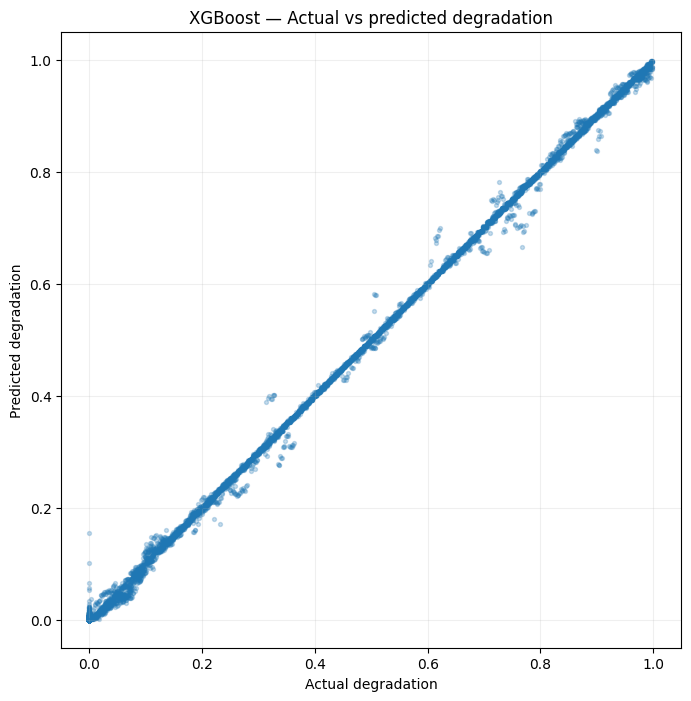

In [19]:
# 17 - Actual vs predicted degradation

plt.figure(figsize=(8,8))
plt.scatter(y_test, test_pred, s=8, alpha=.25)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Actual degradation")
plt.ylabel("Predicted degradation")
plt.title("XGBoost — Actual vs predicted degradation")
plt.grid(alpha=.2)
plt.show()

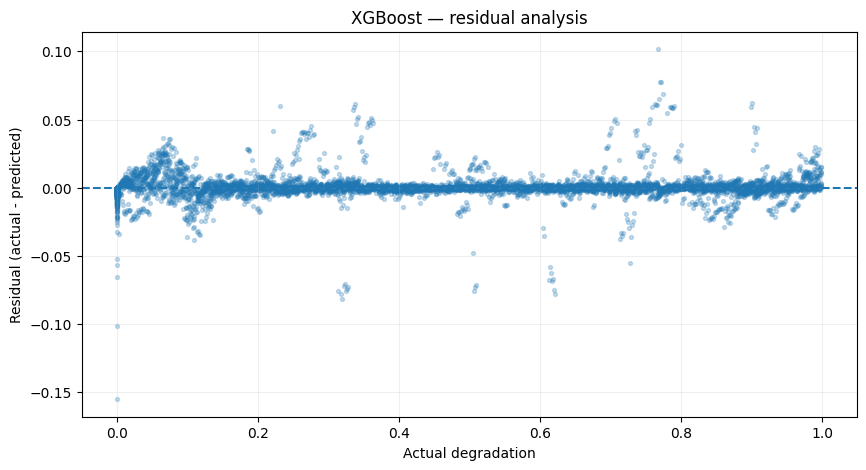

Residual mean: 6.593237898551241e-05
Residual std : 0.005254584457784544


In [20]:
# 18 - Residual analysis

residual = y_test.to_numpy() - test_pred

plt.figure(figsize=(10,5))
plt.scatter(y_test, residual, s=8, alpha=.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual degradation")
plt.ylabel("Residual (actual - predicted)")
plt.title("XGBoost — residual analysis")
plt.grid(alpha=.2)
plt.show()

print("Residual mean:", residual.mean())
print("Residual std :", residual.std())

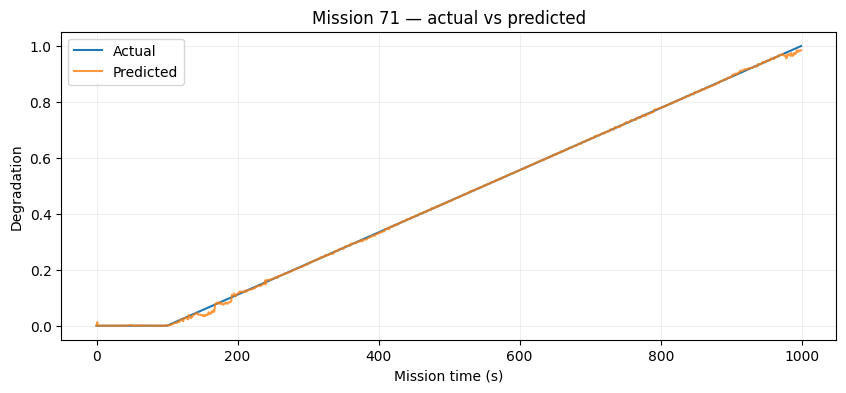

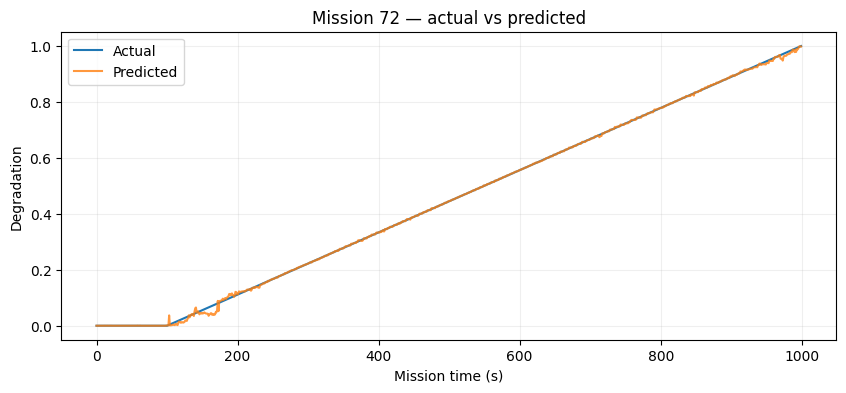

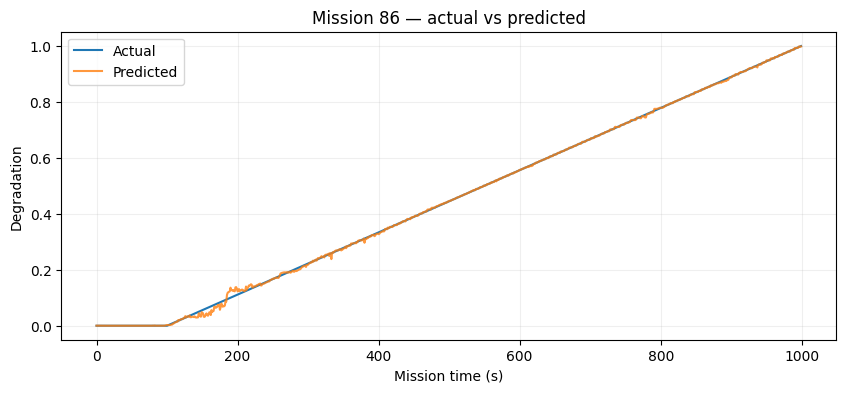

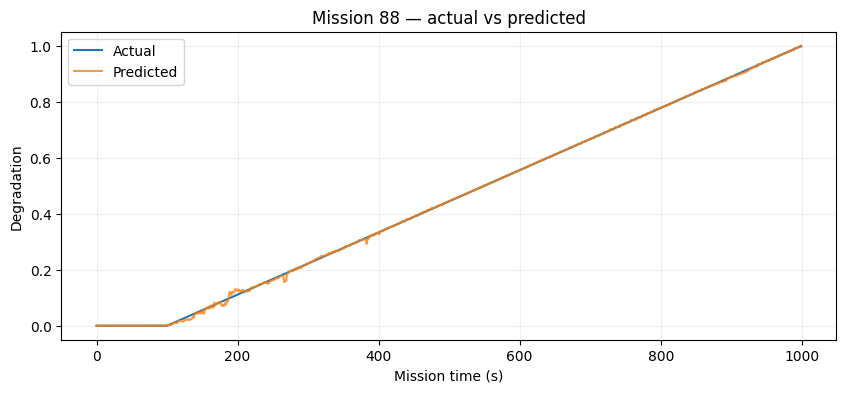

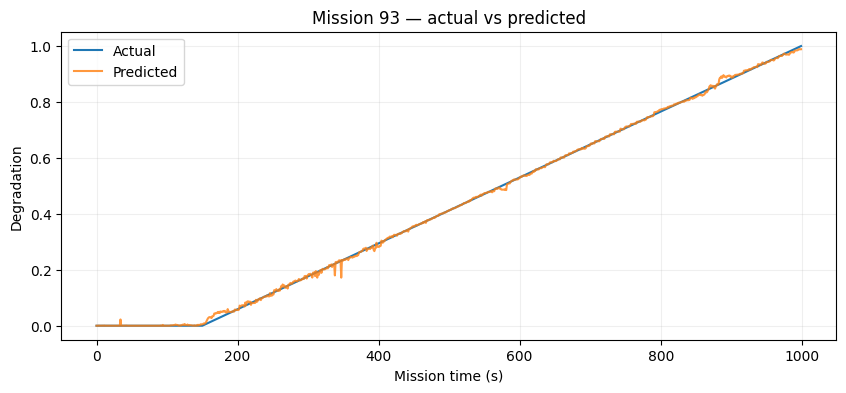

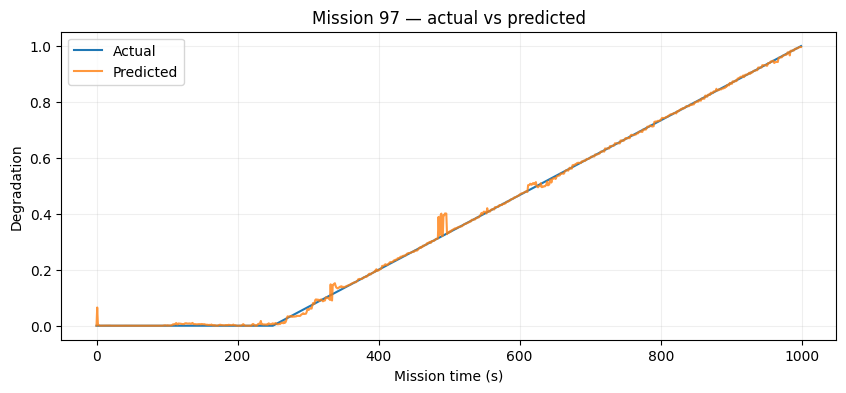

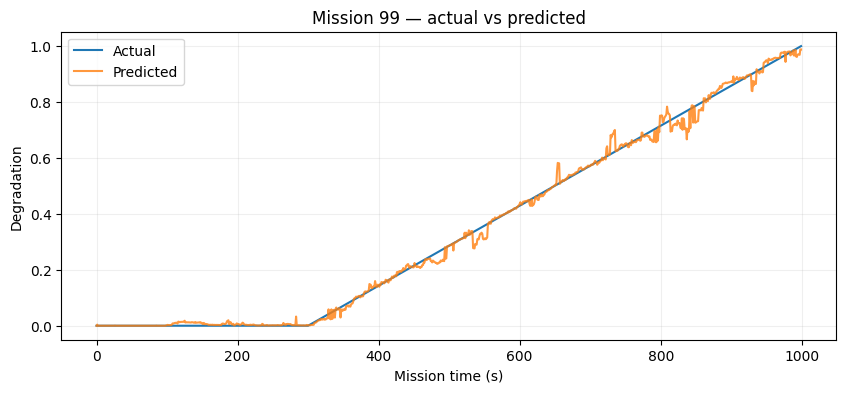

In [21]:
# 19 - Mission-wise degradation trajectories on unseen missions

test_results = test_df[["mission_id","timestamp_s",TARGET]].copy()
test_results["predicted_degradation"] = test_pred

for mission in [71,72,86,88,93,97,99]:
    mdf = test_results[test_results.mission_id == mission].sort_values("timestamp_s")
    if len(mdf) == 0:
        continue

    plt.figure(figsize=(10,4))
    plt.plot(mdf.timestamp_s, mdf[TARGET], label="Actual")
    plt.plot(mdf.timestamp_s, mdf.predicted_degradation, label="Predicted", alpha=.8)
    plt.xlabel("Mission time (s)")
    plt.ylabel("Degradation")
    plt.title(f"Mission {mission} — actual vs predicted")
    plt.ylim(-.05, 1.05)
    plt.grid(alpha=.2)
    plt.legend()
    plt.show()

In [22]:
# 20 - Fault-wise error analysis (interpretation only; fault_type is NOT a feature)

fault_eval = test_df[["fault_type",TARGET]].copy()
fault_eval["prediction"] = test_pred
fault_eval["abs_error"] = np.abs(fault_eval[TARGET] - fault_eval["prediction"])

fault_summary = fault_eval.groupby("fault_type").agg(
    samples=("degradation","size"),
    MAE=("abs_error","mean"),
    RMSE=("abs_error", lambda x: np.sqrt(np.mean(x**2)))
).sort_values("MAE")

display(fault_summary)

,samples,MAE,RMSE
fault_type,,,
normal,15401,0.00037,0.00245
injector_degradation,1708,0.00248,0.00508
lubrication_degradation,1708,0.00259,0.00506
overheating,807,0.00367,0.00583
misfire,712,0.00435,0.00992
sensor_fault,664,0.01364,0.02134


,importance
vibration_rms_rollmean30,0.65844
vibration_rms_rollmean15,0.08075
pressure_kPa,0.07800
physics_residual_C,0.07276
altitude_m,0.06240
air_mass_flow_kg_s_rollmean15,0.00945
egt_residual_rollmean30,0.00645
oil_pressure_bar_rollmean30,0.00511
air_mass_flow_kg_s_rollmean30,0.00401
cht_C_rollstd30,0.00289


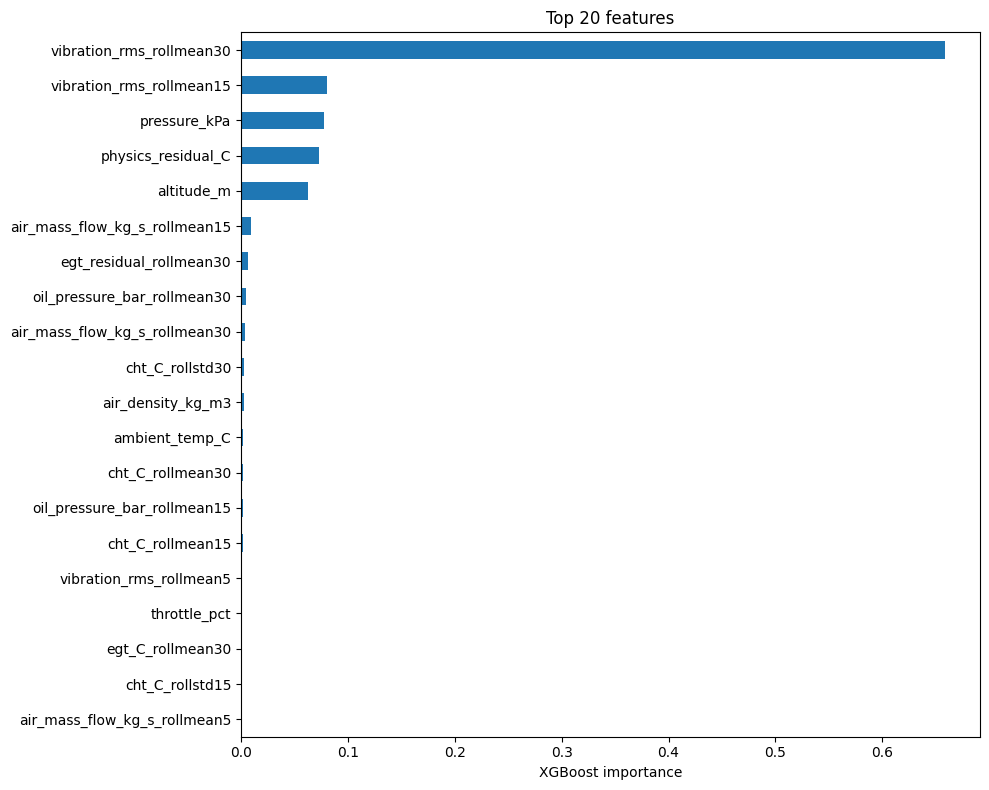

In [23]:
# 21 - Native XGBoost feature importance

importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importance.head(25).to_frame("importance"))

plt.figure(figsize=(10,8))
importance.head(20).sort_values().plot(kind="barh")
plt.xlabel("XGBoost importance")
plt.title("Top 20 features")
plt.tight_layout()
plt.show()

In [24]:
# 22 - Permutation importance on validation sample

perm_n = min(5000, len(X_val))
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_val), size=perm_n, replace=False)

perm = permutation_importance(
    best_model, X_val.iloc[idx], y_val.iloc[idx],
    scoring="neg_mean_absolute_error",
    n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

,feature,importance_mean,importance_std
81,vibration_rms_rollmean30,0.11208,0.00143
22,physics_residual_C,0.04098,0.00051
0,altitude_m,0.03300,0.00040
79,vibration_rms_rollmean15,0.02179,0.00009
2,pressure_kPa,0.01425,0.00024
1,ambient_temp_C,0.00795,0.00023
72,oil_pressure_bar_rollmean30,0.00532,0.00009
54,cht_C_rollmean30,0.00433,0.00007
3,air_density_kg_m3,0.00331,0.00008
52,cht_C_rollmean15,0.00293,0.00011


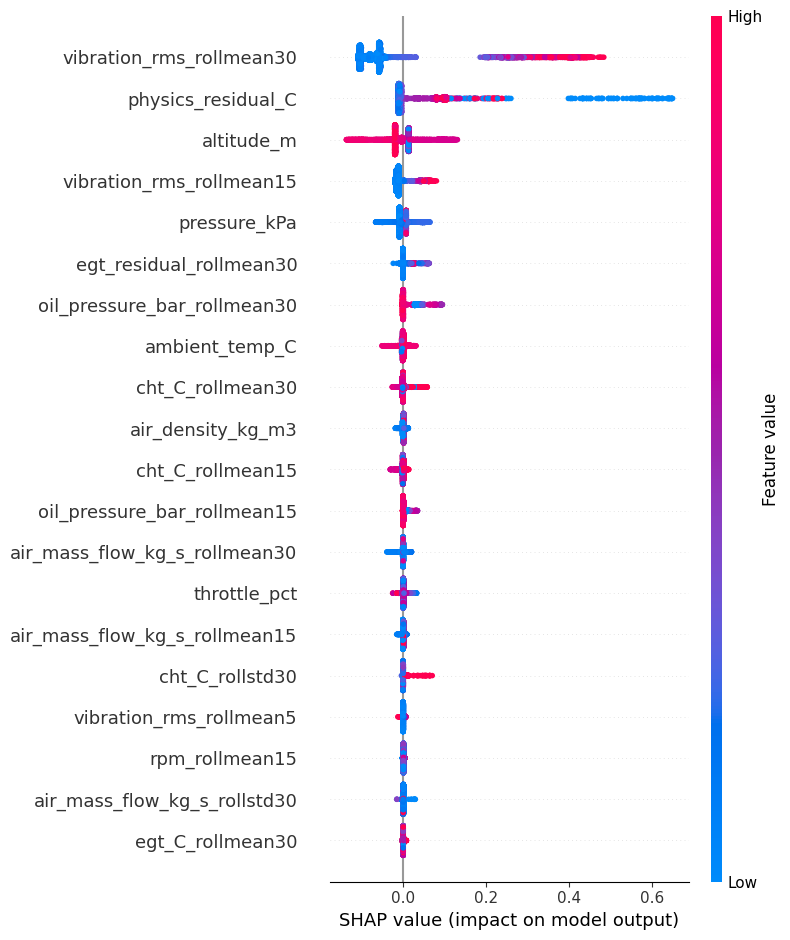

In [25]:
# 23 - SHAP summary on a manageable test sample

try:
    import shap
    shap_n = min(5000, len(X_test))
    idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=shap_n, replace=False)
    X_shap = X_test.iloc[idx]

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP skipped:", repr(e))
    print("If necessary, run: !pip install -q shap")

In [26]:
# 24 - Save deployment artifacts

ARTIFACT_DIR = "ps26054_xgb_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

best_model.save_model(os.path.join(ARTIFACT_DIR, "xgb_degradation_model.json"))

with open(os.path.join(ARTIFACT_DIR, "feature_columns.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

with open(os.path.join(ARTIFACT_DIR, "feature_config.json"), "w") as f:
    json.dump({
        "target": TARGET,
        "excluded_columns": EXCLUDE,
        "physics_features": ["physics_residual_C","rpm_residual","egt_residual"],
        "ratio_features": ["fuel_air_ratio","power_per_fuel","torque_per_rpm","power_per_air"],
        "temporal_columns": TEMPORAL_COLS,
        "temporal_lags": [1,5,10],
        "rolling_windows": [5,15,30],
        "output_range": [0,1],
        "random_state": RANDOM_STATE
    }, f, indent=2)

print("Saved artifacts:", os.listdir(ARTIFACT_DIR))

Saved artifacts: ['feature_columns.json', 'feature_config.json', 'xgb_degradation_model.json']


In [32]:
#25 - Load realtime predictions generated by the model

pred = pd.read_csv("realtime_predictions.csv")

print("Prediction shape:", pred.shape)
display(pred.head())

Prediction shape: (21000, 6)


,stream_row_id,mission_id,timestamp_s,degradation_predicted,degradation,absolute_error
0,0,1,0,0.00019,0.00000,0.00019
1,1,1,1,0.00000,0.00000,0.00000
2,2,1,2,0.00000,0.00000,0.00000
3,3,1,3,0.00000,0.00000,0.00000
4,4,1,4,0.00000,0.00000,0.00000


In [33]:
#26 - Load the hidden evaluation ground truth

ground_truth = pd.read_csv("realtime_ground_truth.csv")

print("Ground truth shape:", ground_truth.shape)
display(ground_truth.head())

Ground truth shape: (21000, 5)


,stream_row_id,mission_id,timestamp_s,degradation,fault_type
0,0,1,0,0.00000,normal
1,1,1,1,0.00000,normal
2,2,1,2,0.00000,normal
3,3,1,3,0.00000,normal
4,4,1,4,0.00000,normal


In [34]:
#27 - Verify that predictions and ground truth refer to exactly the same samples

key_cols = ["stream_row_id", "mission_id", "timestamp_s"]

assert len(pred) == len(ground_truth)

merged = pred[key_cols + ["degradation_predicted"]].merge(
    ground_truth[key_cols + ["degradation"]],
    on=key_cols,
    how="inner",
    validate="one_to_one"
)

assert len(merged) == len(pred)

print("✓ Every prediction matched exactly one ground-truth sample.")
print("✓ No missing evaluation samples.")
print("✓ No duplicate stream IDs.")

✓ Every prediction matched exactly one ground-truth sample.
✓ No missing evaluation samples.
✓ No duplicate stream IDs.


In [35]:
#28 - Final realtime replay evaluation

y_true = merged["degradation"]
y_pred = np.clip(merged["degradation_predicted"], 0, 1)

realtime_mae = mean_absolute_error(y_true, y_pred)
realtime_rmse = mean_squared_error(y_true, y_pred) ** 0.5
realtime_r2 = r2_score(y_true, y_pred)
realtime_median_ae = np.median(np.abs(y_true - y_pred))
realtime_max_ae = np.max(np.abs(y_true - y_pred))

realtime_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Median Absolute Error",
        "Maximum Absolute Error"
    ],
    "Value": [
        realtime_mae,
        realtime_rmse,
        realtime_r2,
        realtime_median_ae,
        realtime_max_ae
    ]
})

display(realtime_metrics)

,Metric,Value
0,MAE,0.00141
1,RMSE,0.00525
2,R²,0.99963
3,Median Absolute Error,0.00003
4,Maximum Absolute Error,0.15502


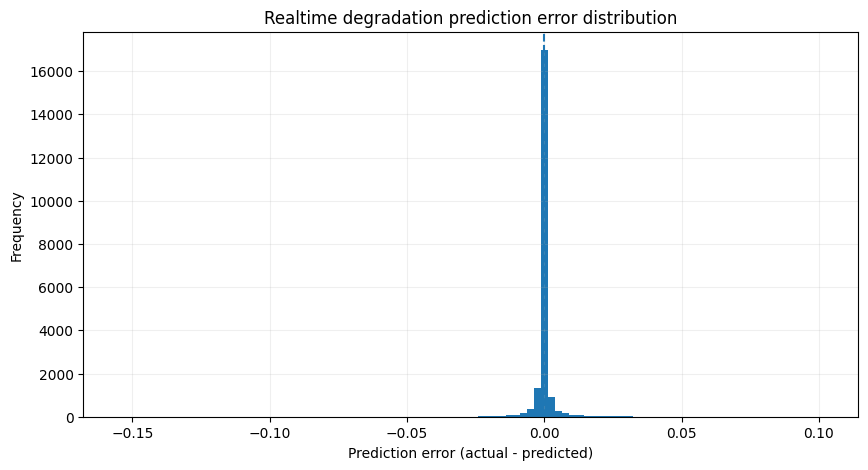

In [36]:
#29 - Prediction error distribution

merged["error"] = merged["degradation"] - merged["degradation_predicted"]
merged["absolute_error"] = merged["error"].abs()

plt.figure(figsize=(10, 5))
plt.hist(merged["error"], bins=100)
plt.axvline(0, linestyle="--")
plt.xlabel("Prediction error (actual - predicted)")
plt.ylabel("Frequency")
plt.title("Realtime degradation prediction error distribution")
plt.grid(alpha=0.2)
plt.show()

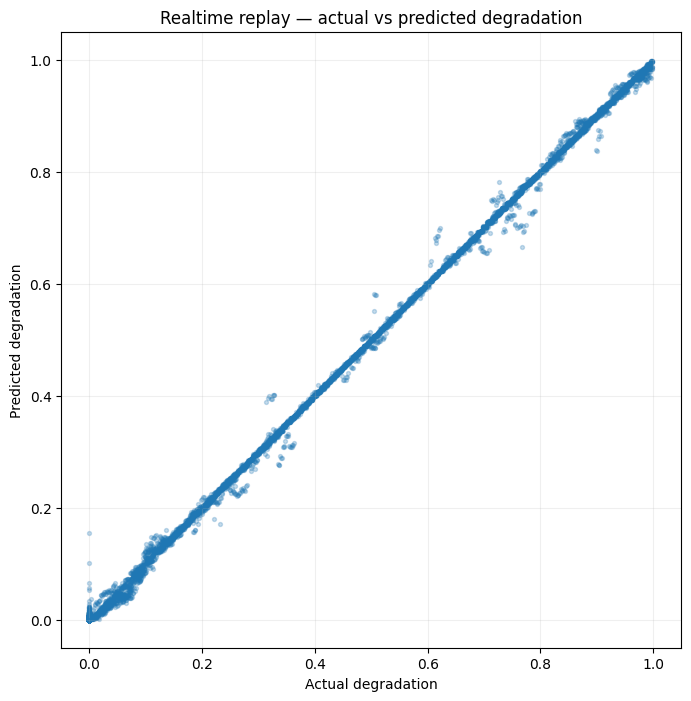

In [37]:
#30 - Realtime replay: actual vs predicted

plt.figure(figsize=(8, 8))
plt.scatter(
    merged["degradation"],
    merged["degradation_predicted"],
    s=8,
    alpha=0.25
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Actual degradation")
plt.ylabel("Predicted degradation")
plt.title("Realtime replay — actual vs predicted degradation")
plt.grid(alpha=0.2)
plt.show()

In [38]:
#31 - Compare batch and realtime predictions if batch predictions are available

comparison = pd.DataFrame({
    "batch": test_pred,
    "realtime": pred["degradation_predicted"].values
})

comparison["difference"] = (
    comparison["batch"] - comparison["realtime"]
).abs()

print("Maximum difference:",
      comparison["difference"].max())

print("Mean difference:",
      comparison["difference"].mean())

Maximum difference: 1.1102230246251565e-16
Mean difference: 1.1801828347854324e-17
